## 1. Setup and Import Libraries
We import essential libraries for data analysis and visualization:
- `pandas` for data manipulation
- `numpy` for numerical operations
- `matplotlib` and `seaborn` for plotting
- `os` for file path handling

We also print the dataset path to confirm it's accessible.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/akard22/videogames101/VideoGamesSales.csv


## 2. Load and Clean Data
We perform several crucial cleaning steps:
- **Remove duplicate rows** using `drop_duplicates()`
- **Drop rows with missing Region** (region is important for regional analysis)
- **Remove dollar sign ($) from `NA_Sales`** and convert to numeric
- **Fill missing sales values** with the column mean
- **Standardize country names**: replace 'USA' with 'United States' and title-case all
- **Rename columns** for clarity (`NA_Sales` → `National Sales`, etc.)
- **Cap outliers** at the 95th percentile to prevent distortion in visualizations

In [2]:
# Read the CSV file
df = pd.read_csv('/kaggle/input/datasets/akard22/videogames101/VideoGamesSales.csv')

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows where Region is null
df = df[df['Region'].notnull()]

# Remove the dollar sign from the NA_Sales column
df['NA_Sales'] = df['NA_Sales'].replace('[$]', '', regex=True)

# Convert the column to numeric values
df['NA_Sales'] = pd.to_numeric(df['NA_Sales'], errors='coerce')

# Fill missing values with mean
Average_Sales = df['NA_Sales'].mean()
df['NA_Sales'] = df['NA_Sales'].fillna(Average_Sales)

# Clean country names
df["Country"] = df["Country"].replace({'USA': 'United States'})
df["Country"] = df["Country"].str.title()

# Rename columns
df = df.rename(columns={
    'NA_Sales': 'National Sales',
    'Global_Sales': 'Global Sales',
    'NA_Profit': 'National Profit',
    'Global_Profit': 'Global Profit'
})

# Cap outliers
sales_cap = df["National Sales"].quantile(0.95)

df['National Sales'] = np.where(
    df['National Sales'] > sales_cap,
    sales_cap,
    df['National Sales']
)

df

,Rank,Name,Platform,Year,Month,Genre,Publisher,Country,City,State,Region,National Sales,Global Sales,National Profit,Global Profit
0,1,Wii Sports,Wii,2010,Jan,Sports,Nintendo,United States,Fairfield,California,West,2.0575,82.74,12.447,24.822
1,2,Super Mario Bros.,NES,2010,Feb,Platform,Nintendo,United States,Edmonds,Washington,West,2.0575,40.24,8.724,12.072
2,3,Mario Kart Wii,Wii,2010,Mar,Racing,Nintendo,United States,Louisville,Kentucky,South,2.0575,35.82,4.755,10.746
3,4,Wii Sports Resort,Wii,2010,Apr,Sports,Nintendo,United States,Round Rock,Texas,Central,2.0575,33.00,4.725,9.900
4,5,Pokemon Red/Pokemon Blue,GB,2010,May,Role-Playing,Nintendo,United States,Nashville,Tennessee,South,2.0575,31.37,3.381,9.411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5904,5890,Crazy Taxi: Catch a Ride,GBA,2017,Sep,Racing,THQ,Australia,Sydney,New South Wales,West,0.2100,0.30,0.063,0.090
5905,5891,MySims Party,DS,2017,Oct,Simulation,Electronic Arts,Australia,Sydney,New South Wales,West,0.1500,0.30,0.045,0.090
5906,5892,Harry Potter and the Order of the Phoenix,X360,2017,Nov,Action,Electronic Arts,Australia,Sydney,New South Wales,West,0.2400,0.30,0.072,0.090
5907,5893,Skylanders: SuperChargers,PS4,2017,Dec,Action,Activision,Australia,Sydney,New South Wales,West,0.1700,0.30,0.051,0.090


## 3. Bar Chart: National Sales by Region and Country
We group the data by Region and Country, then sum National Sales.
The bar chart helps compare sales across regions (West, Central, South, East) and countries.
This reveals which geographic areas generate the most revenue.

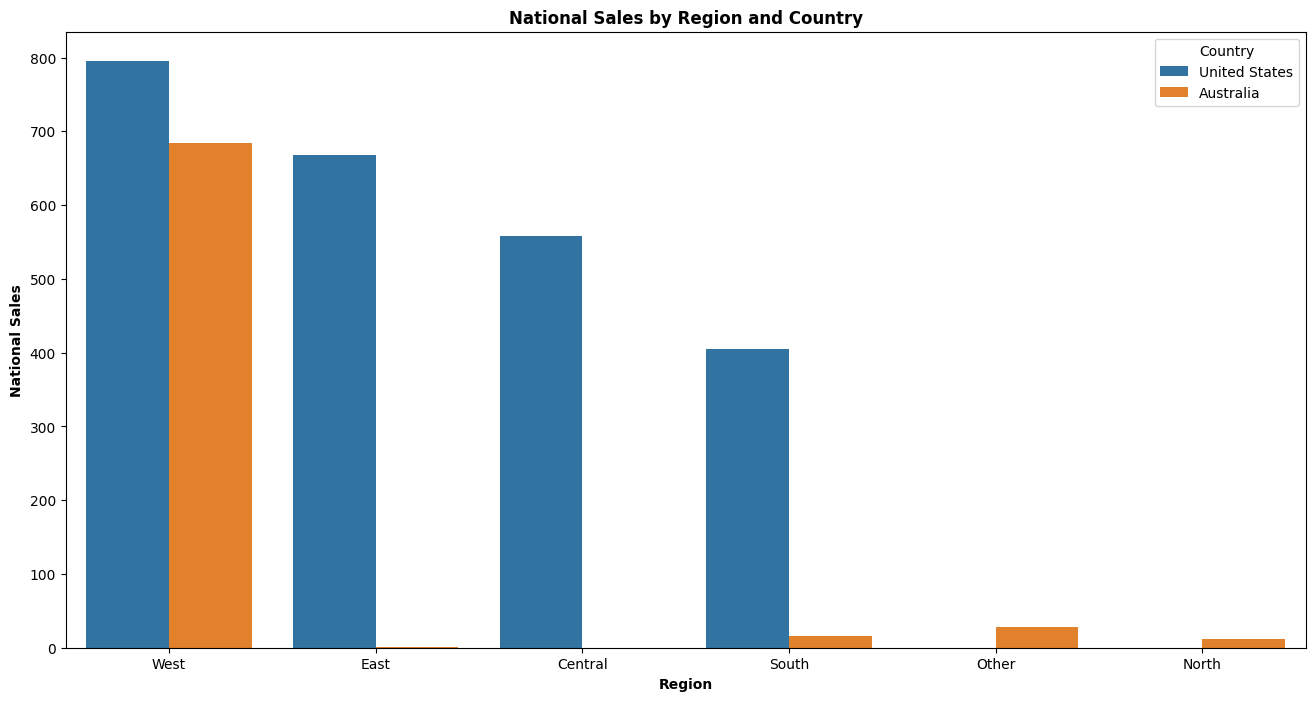

In [3]:
#create a bar Chart

National_Sales=df.groupby(['Region','Country'])['National Sales'].sum().reset_index().sort_values(by='National Sales', ascending=False)
National_Sales
plt.figure(figsize=(16, 8))
sns.barplot(data=National_Sales, x='Region', y='National Sales',hue='Country')
plt.title('National Sales by Region and Country',fontweight='bold')
plt.xlabel('Region',fontweight='bold')
plt.ylabel('National Sales',fontweight='bold')
plt.show()

## 4. Box Plot: National Sales Distribution by Country and Genre
Box plots show the spread, median, and outliers of National Sales.
We split by Country and hue by Genre.
Mean values are marked with white circles.
This helps identify which genres perform best in different countries.

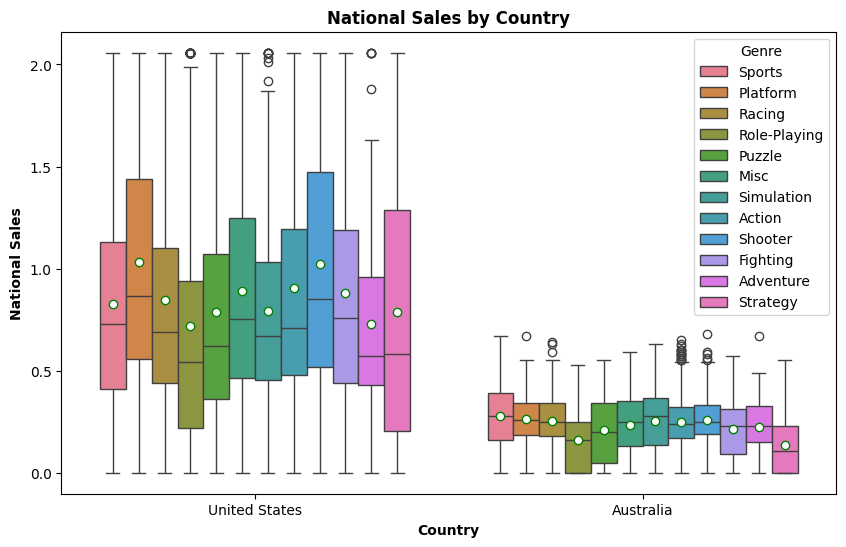

In [4]:
#Create Box Plot
# ,meanprops={"marker":"o"
#                                                                                   ,"markerfacecolor":"white"
#                                                                                   ,"markersize":"3"
#                                                                                   ,"markeredgecolor":"green"}
plt.figure(figsize=(10, 6))
sns.boxplot(x='Country', y='National Sales', data=df,showmeans=True,hue='Genre',meanprops={"marker":"o"
                                                                                   ,"markerfacecolor":"white"
                                                                                   ,"markersize":"6"
                                                                                 ,"markeredgecolor":"green"})

plt.title('National Sales by Country',fontweight='bold')
plt.xlabel('Country',fontweight='bold')
plt.ylabel('National Sales',fontweight='bold')
plt.show()

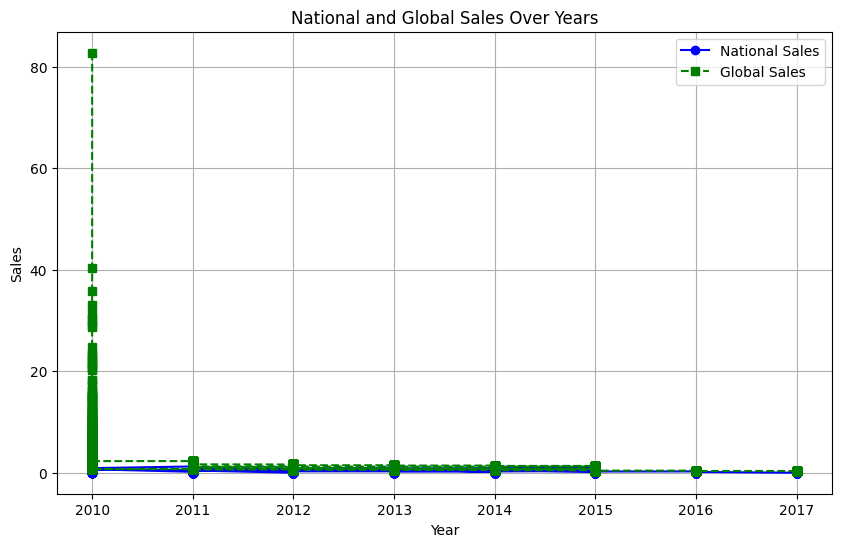

In [5]:
# Create a line chart
plt.figure(figsize=(10, 6))

# Line for National Sales
plt.plot(df['Year'], df['National Sales'], marker='o', linestyle='-', color='b', label='National Sales')

# Line for Global Sales
plt.plot(df['Year'], df['Global Sales'], marker='s', linestyle='--', color='g', label='Global Sales')

# Adding titles and labels
plt.title('National and Global Sales Over Years')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()

# Display the line chart
plt.grid(True)
plt.show()

## 5. Pie Charts: National vs Global Sales by Country

We create two pie charts:
- Left: National Sales share per country
- Right: Global Sales share per country

This visualizes the dominance of certain countries (e.g., United States, Australia) in both markets.

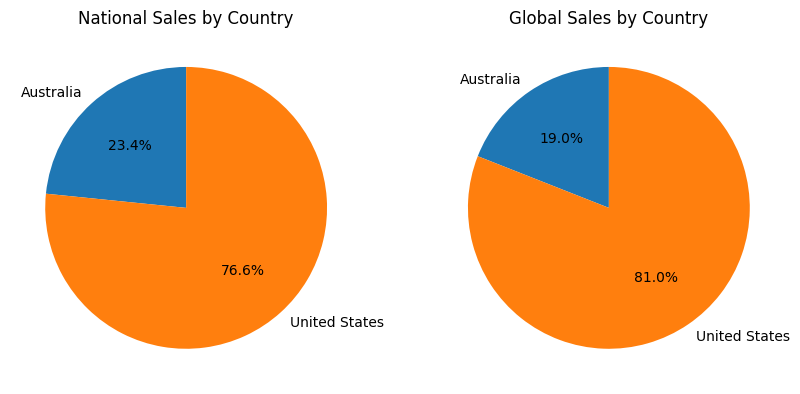

In [6]:
# Create pie charts
Sales = df.groupby(['Country'])[['National Sales', 'Global Sales']].sum().reset_index()
Country = Sales['Country']
National_Sales = Sales['National Sales']
Global_Sales = Sales['Global Sales']

fig, axs = plt.subplots(1, 2, figsize=(10, 7))

axs[0].pie(National_Sales, labels=Country, autopct='%1.1f%%', startangle=90)
axs[0].set_title('National Sales by Country')

axs[1].pie(Global_Sales, labels=Country, autopct='%1.1f%%', startangle=90)
axs[1].set_title('Global Sales by Country')

plt.show()

## 6. Line Chart: Sales Trend Over Years

We plot National Sales (solid line) and Global Sales (dashed line) across different years.

This helps detect trends, peaks, or declines over time.

**Note:** The drop in 2017 may be due to missing data rather than an actual sales collapse.

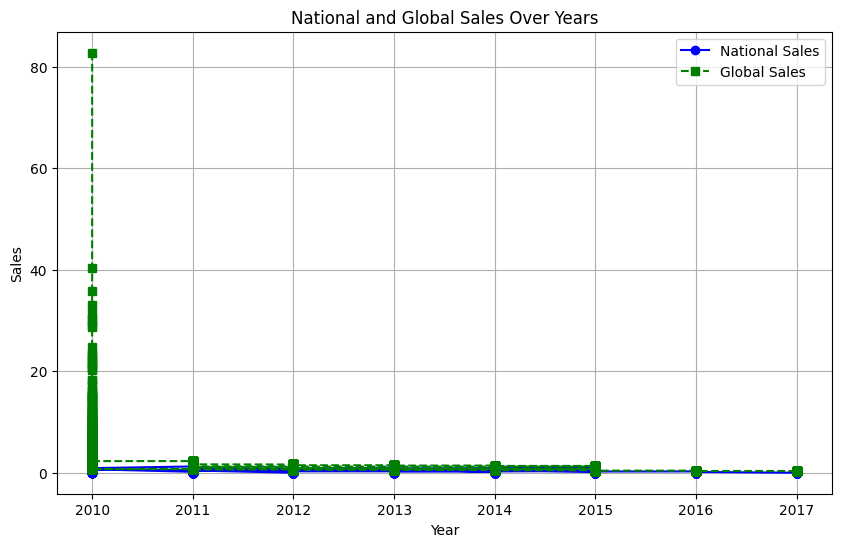

In [7]:
# Create line chart
plt.figure(figsize=(10, 6))

plt.plot(df['Year'], df['National Sales'], marker='o', linestyle='-', color='b', label='National Sales')
plt.plot(df['Year'], df['Global Sales'], marker='s', linestyle='--', color='g', label='Global Sales')

plt.title('National and Global Sales Over Years')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()